## Ex 1

In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [300]:
m = 10
n = 6
A = np.random.rand(m, n)
U, s, VT = np.linalg.svd(A, full_matrices=True)
print(U.shape, s.shape, VT.shape)


(10, 10) (6,) (6, 6)


In [301]:
S = np.zeros((m, n))
S[:n, :n] = np.diag(s)
S.shape

(10, 6)

In [302]:
np.linalg.norm(A - U @ S @ VT) 

np.float64(3.338569072675898e-15)

In [303]:
print('Singular values of A:', s)

Singular values of A: [4.35649045 1.19872561 0.98783948 0.86912787 0.62392156 0.48946306]


## Ex 2

In [304]:
def compress_matrix(U, S, VT, k):
    """Compress matrix using top k singular values and vectors."""
    U_k = U[:, :k]
    S_k = S[:k, :k]
    VT_k = VT[:k, :]
    A_k = U_k @ S_k @ VT_k
    return A_k

In [305]:
errors = []
for k in range(len(s)):
    A_k = compress_matrix(U, S, VT, k+1)
    error = np.linalg.norm(A - A_k)
    errors.append(error)
    print(f'Error with k={k+1}: {error}')

Error with k=1: 1.9485906122761287
Error with k=2: 1.5362494232739137
Error with k=3: 1.1765353598938788
Error with k=4: 0.7930020184612924
Error with k=5: 0.48946305907002596
Error with k=6: 3.338569072675898e-15


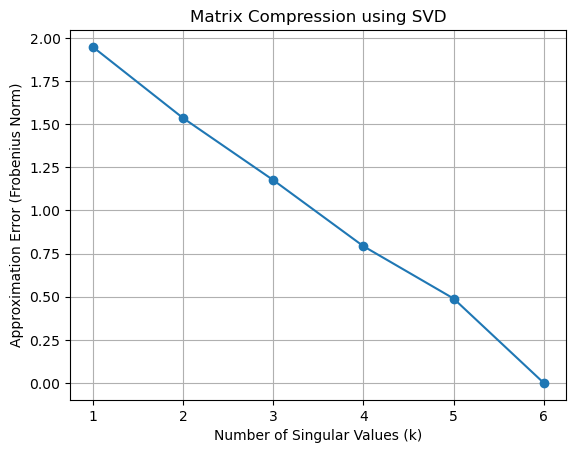

In [306]:
plt.plot(range(1, len(s)+1), errors, marker='o')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Approximation Error (Frobenius Norm)')
plt.title('Matrix Compression using SVD')
plt.grid()
plt.show()


## Ex 2

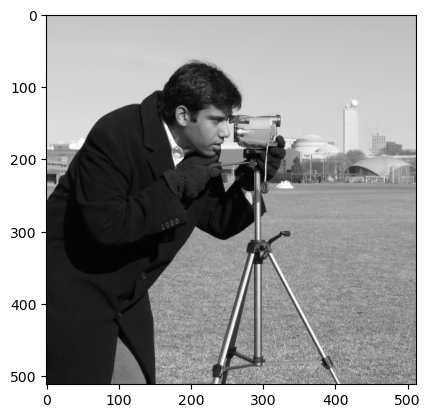

In [307]:
import skimage 

x = skimage.data.camera()
plt.imshow(x, cmap="gray")
plt.show()

In [308]:
U, s, VT = np.linalg.svd(x, full_matrices=False)
print("SVD: ",U.shape, " @ ", s.shape," @ ", VT.shape)

SVD:  (512, 512)  @  (512,)  @  (512, 512)


In [309]:
k_values = [5, 20, 50, 100, 200]

compression_results = pd.DataFrame(columns=['k', 'Compressed_Image', 'Error', 'compression factor'])

for k in k_values:
    x_k = compress_matrix(U, np.diag(s), VT, k)
    error = np.linalg.norm(x - x_k)
    m = U.shape[0]
    n = VT.shape[1]
    compression_factor = 1 - (k*(m + 1 + n) / (m*n))
    compression_results.loc[len(compression_results)] = [k, x_k, error, compression_factor]

display(compression_results.drop(columns=['Compressed_Image']))

,k,Error,compression factor
0,5,13086.868265,0.980450
1,20,7699.909142,0.921799
2,50,4836.068908,0.804497
3,100,2992.144382,0.608994
4,200,1342.358197,0.217987


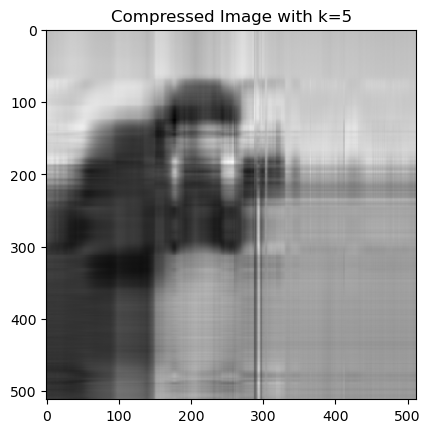

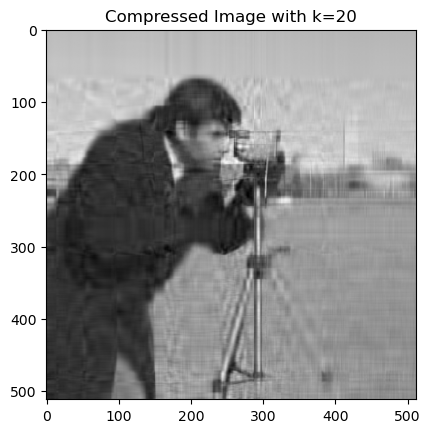

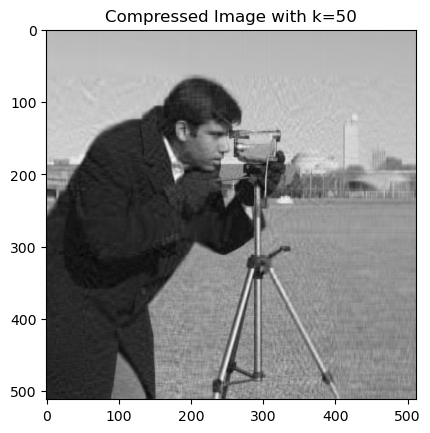

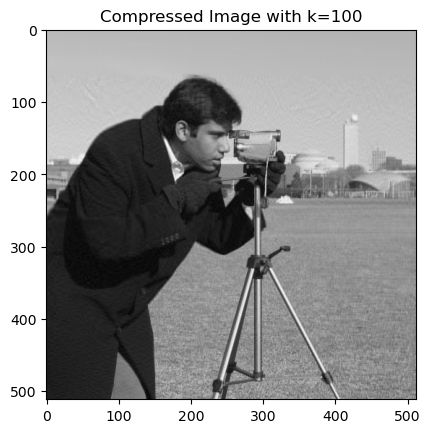

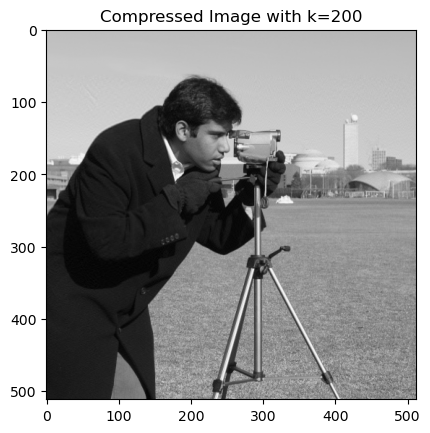

In [310]:
for index, row in compression_results.iterrows():
    plt.imshow(row['Compressed_Image'], cmap='gray')
    plt.title(f'Compressed Image with k={row["k"]}')
    plt.show()

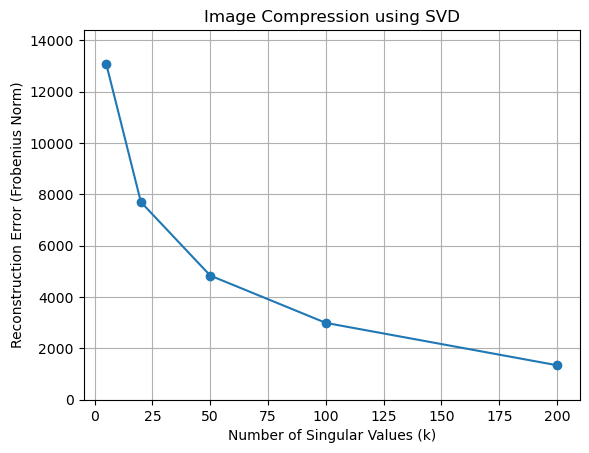

In [311]:
# plot reconstruction error vs k
plt.plot(compression_results['k'], compression_results['Error'], marker='o')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Reconstruction Error (Frobenius Norm)')
plt.ylim(0, max(compression_results['Error']) * 1.1)
plt.title('Image Compression using SVD')
plt.grid()
plt.show()

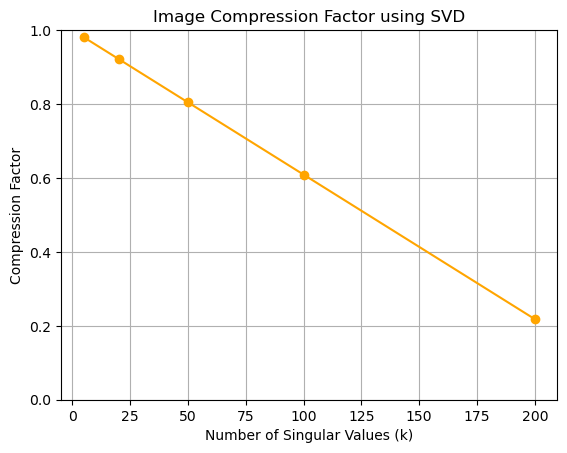

In [312]:
plt.plot(compression_results['k'], compression_results['compression factor'], marker='o', color='orange')
plt.xlabel('Number of Singular Values (k)')
plt.ylabel('Compression Factor')
plt.ylim(0, 1)
plt.title('Image Compression Factor using SVD')
plt.grid()
plt.show()

## Ex 5

In [313]:
import numpy as np
 

df = pd.read_csv('./MNIST.csv')
df.shape

(42000, 785)

In [314]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [315]:
X = df.drop(columns=['label']).values
y = df['label'].values

print(f"Shape of the data: {X.shape}, Labels: {y.shape}")

Shape of the data: (42000, 784), Labels: (42000,)


In [316]:
filter_3or4 = (y==3) | (y==4)

X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

print(f"Final shape of X: {X_filtered.shape}. Final shape of Y: {Y_filtered.shape}")
print(f"Number of class 3 samples: {np.sum(Y_filtered==3)}")
print(f"Number of class 4 samples: {np.sum(Y_filtered==4)}")

Final shape of X: (8423, 784). Final shape of Y: (8423,)
Number of class 3 samples: 4351
Number of class 4 samples: 4072


In [317]:
N = X_filtered.shape[0]
random_indices = np.random.permutation(N)

N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]

X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]

print(f"Train set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Train set: 6738 samples, Test set: 1685 samples


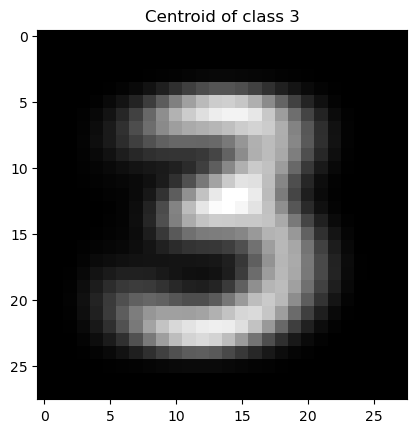

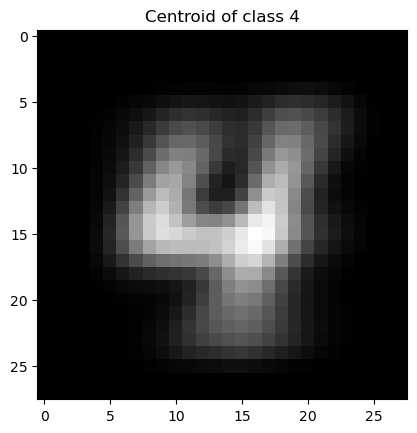

In [318]:
X_3 = X_filtered[Y_filtered==3]
X_4 = X_filtered[Y_filtered==4]

centroid_of_X_3 = np.mean(X_3, axis=0)
centroid_of_X_4 = np.mean(X_4, axis=0)

# Visualize centroids
img_3 = np.reshape(centroid_of_X_3, (28, 28))
plt.imshow(img_3, cmap='gray')
plt.title('Centroid of class 3')
plt.show()

img_4 = np.reshape(centroid_of_X_4, (28, 28))
plt.imshow(img_4, cmap='gray')
plt.title('Centroid of class 4')
plt.show()

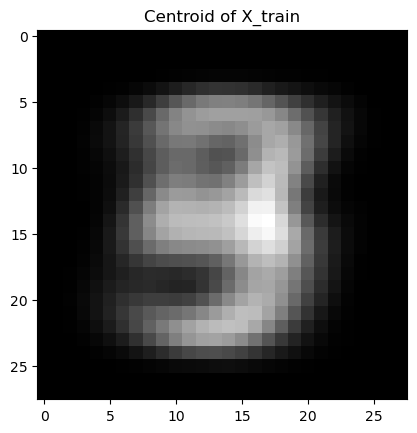

In [319]:
centroid_of_X_train = np.mean(X_train, axis=0)
centroid_of_X_test = np.mean(X_test, axis=0)

centroid_of_X_train_img = np.reshape(centroid_of_X_train, (28, 28))
plt.imshow(centroid_of_X_train_img, cmap='gray')
plt.title('Centroid of X_train')
plt.show()

In [320]:
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

In [321]:
k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T


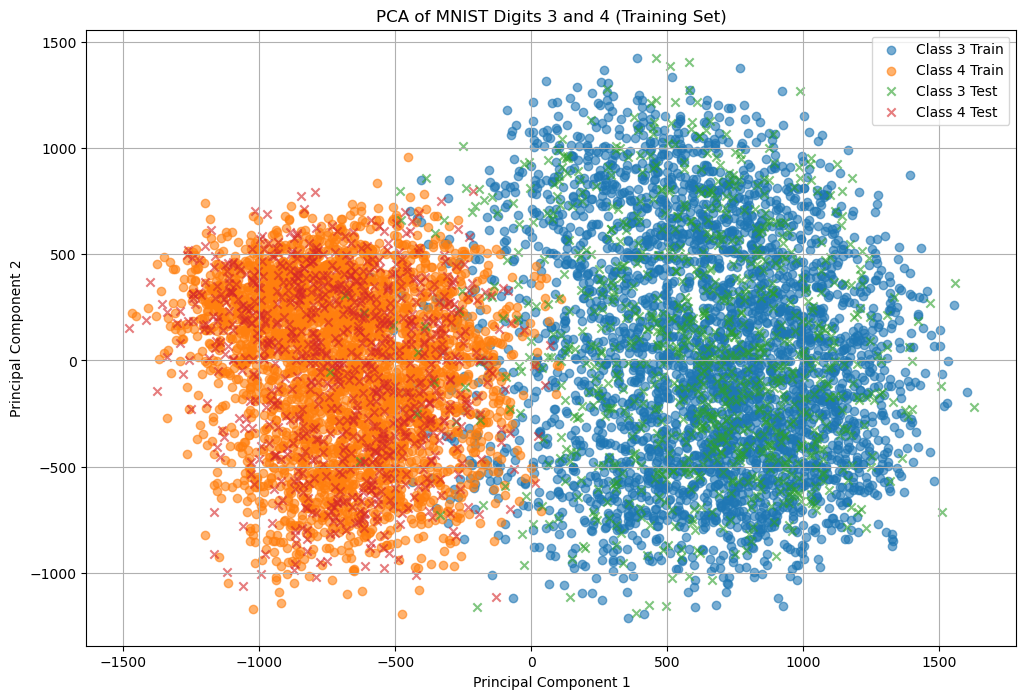

In [322]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], label='Class 4 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [323]:
filter_5or8 = (y==5) | (y==8)
X_filtered = X[filter_5or8]
Y_filtered = y[filter_5or8]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T


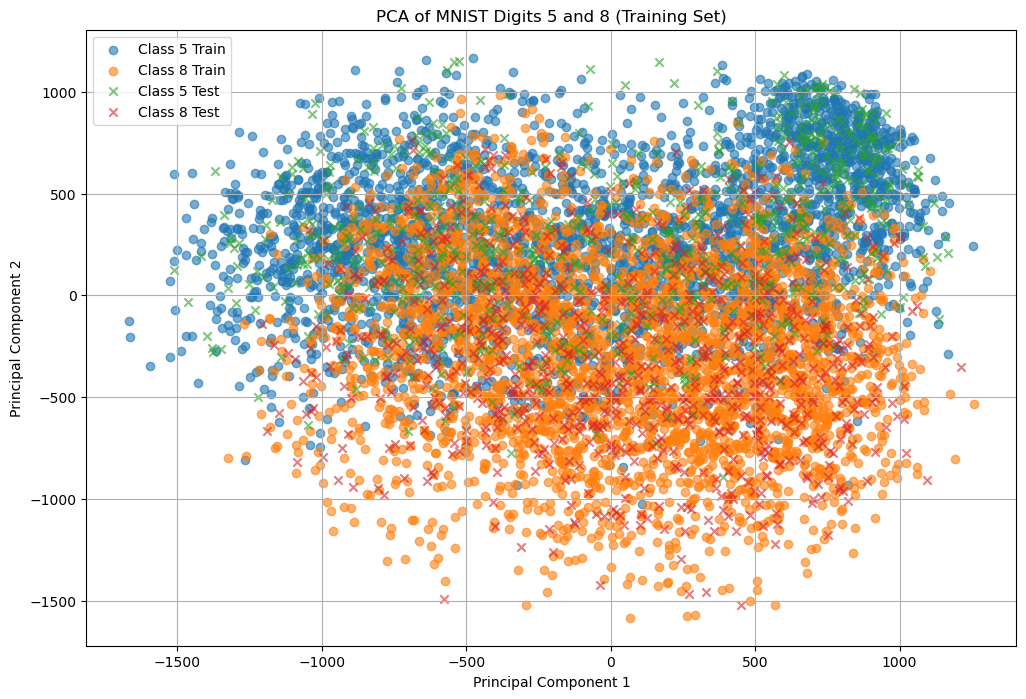

In [324]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==5, 0], Z_train[Y_train==5, 1], label='Class 5 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==8, 0], Z_train[Y_train==8, 1], label='Class 8 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==5, 0], Z_test[Y_test==5, 1], label='Class 5 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==8, 0], Z_test[Y_test==8, 1], label='Class 8 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 5 and 8 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [325]:
filter_1or7 = (y==1) | (y==7)
X_filtered = X[filter_1or7]
Y_filtered = y[filter_1or7]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

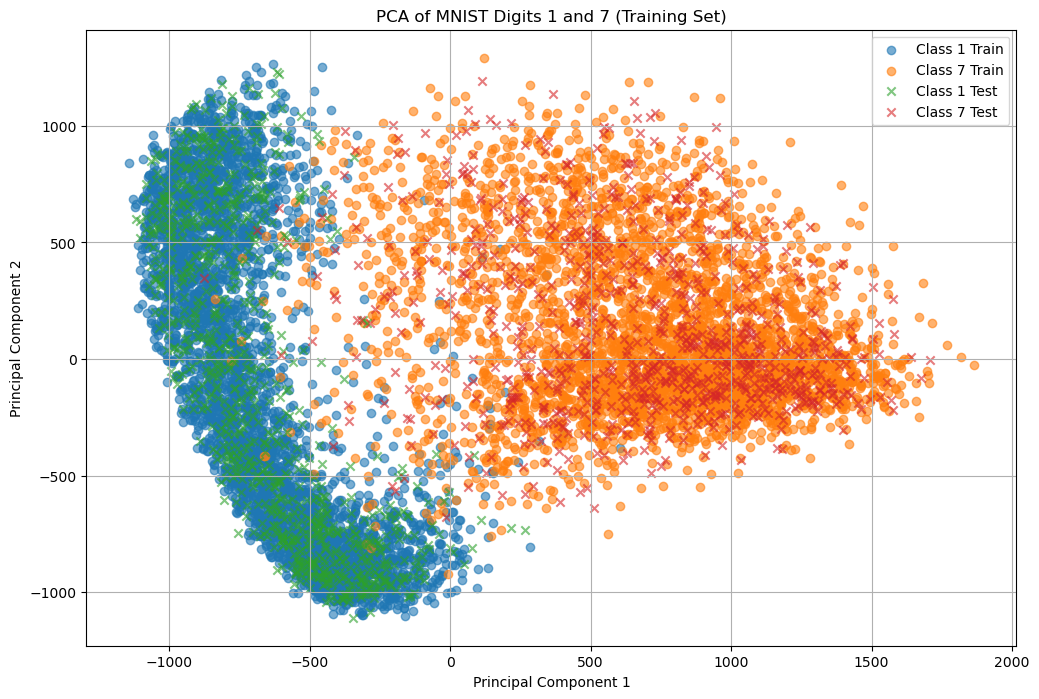

In [326]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==1, 0], Z_train[Y_train==1, 1], label='Class 1 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==7, 0], Z_train[Y_train==7, 1], label='Class 7 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==1, 0], Z_test[Y_test==1, 1], label='Class 1 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==7, 0], Z_test[Y_test==7, 1], label='Class 7 Test', alpha=0.6, marker='x')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 1 and 7 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [366]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 3
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

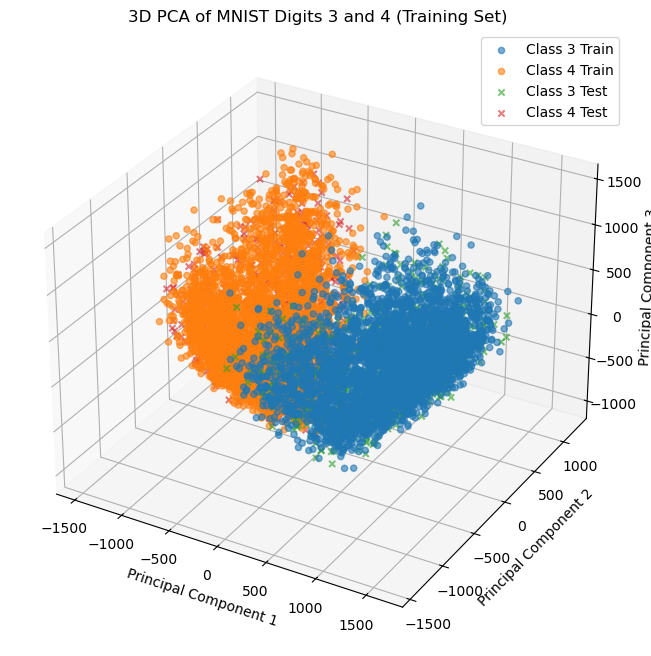

In [368]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], Z_train[Y_train==3, 2], label='Class 3 Train', alpha=0.6)
ax.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], Z_train[Y_train==4, 2], label='Class 4 Train', alpha=0.6)
ax.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], Z_test[Y_test==3, 2], label='Class 3 Test', alpha=0.6, marker='x')
ax.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], Z_test[Y_test==4, 2], label='Class 4 Test', alpha=0.6, marker='x')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.show()

## Ex6

In [369]:
filter_3or4 = (y==3) | (y==4)
X_filtered = X[filter_3or4]
Y_filtered = y[filter_3or4]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]


centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

In [371]:
def sigmoid(t):
    t = np.clip(t, -500, 500)
    return 1 / (1 + np.exp(-t))

def l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return - np.sum(Y * np.log(Y_hat) + (1-Y) * np.log(1 - Y_hat))

def grad_l(Theta, X, Y):
    Y_hat = sigmoid(X @ Theta)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return X.T @ (Y_hat - Y)

def accuracy(Theta, X, Y):
    preds = sigmoid(X @ Theta) >= 0.5
    return (preds == Y).mean()

def ADAM(l, grad_l, X, Y, Theta0, lr=1e-3, batch_size=32, epochs=200,  beta1=0.9, beta2=0.999, eps=1e-8):
    epoch_loss = []
    epoch_acc = []

    Theta = Theta0
    
    m = np.zeros_like(Theta)
    v = np.zeros_like(Theta)
    t = 0
    
    for epoch in range(epochs):
        N = len(X)
        shuffle_idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])

            t += 1
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad * grad)
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            Theta -= lr * (m_hat / (np.sqrt(v_hat) + eps))


        epoch_loss.append(l(Theta, X, Y))
        epoch_acc.append(accuracy(Theta, X, Y))
            # Update the loss_val list

    return Theta, epoch, epoch_loss, epoch_acc

In [370]:
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))

# Convert labels to binary: 0 for class 3, 1 for class 4
Y_train_binary = (Y_train == 4).astype(int)
Y_test_binary = (Y_test == 4).astype(int)
display_labels = ['3', '4']

In [374]:
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)

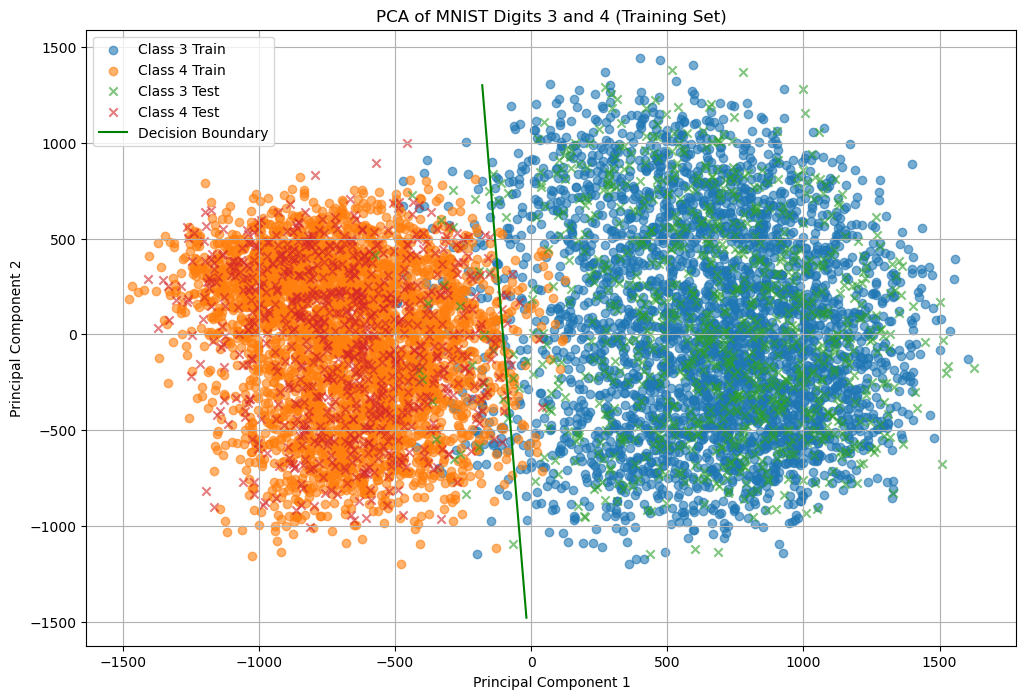

In [380]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6, marker='x')
plt.scatter(Z_test[Y_test==4, 0], Z_test[Y_test==4, 1], label='Class 4 Test', alpha=0.6, marker='x')

pc1_q1 = np.percentile(Z_train[:, 0], 48)
pc1_q3 = np.percentile(Z_train[:, 0], 51)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Decision Boundary', color='green')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [381]:
def classification_report(Y, Y_hat):
    # Get unique classes
    classes = np.unique(np.concatenate([Y, Y_hat]))
    
    # Overall accuracy
    accuracy = np.sum(Y == Y_hat) / len(Y)
    
    # Build confusion matrix
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int)
    for i, true_class in enumerate(classes):
        for j, pred_class in enumerate(classes):
            confusion_matrix[i, j] = np.sum((Y == true_class) & (Y_hat == pred_class))
    
    # Compute per-class metrics
    precision_per_class = []
    recall_per_class = []
    f1_per_class = []
    
    for i, cls in enumerate(classes):
        TP = confusion_matrix[i, i]
        FP = np.sum(confusion_matrix[:, i]) - TP
        FN = np.sum(confusion_matrix[i, :]) - TP
        TN = np.sum(confusion_matrix) - TP - FP - FN
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_per_class.append(precision)
        recall_per_class.append(recall)
        f1_per_class.append(f1)
    
    # Macro-averaged metrics
    macro_precision = np.mean(precision_per_class)
    macro_recall = np.mean(recall_per_class)
    macro_f1 = np.mean(f1_per_class)
    
    report = {
        'Accuracy': accuracy,
        'Macro-Precision': macro_precision,
        'Macro-Recall': macro_recall,
        'Macro-F1': macro_f1,
        'Confusion Matrix': confusion_matrix,
        'Classes': classes
    }
    return report

In [382]:
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)

logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

print("\nClassification Report - Test Set")
for key, value in logistic_regression_report.items():
    print(f"{key}: {value}")


Classification Report - Test Set
Accuracy: 0.9780415430267062
Macro-Precision: 0.9774752824858757
Macro-Recall: 0.9786475633826348
Macro-F1: 0.9779607829551604
Confusion Matrix: [[875  27]
 [ 10 773]]
Classes: [0 1]


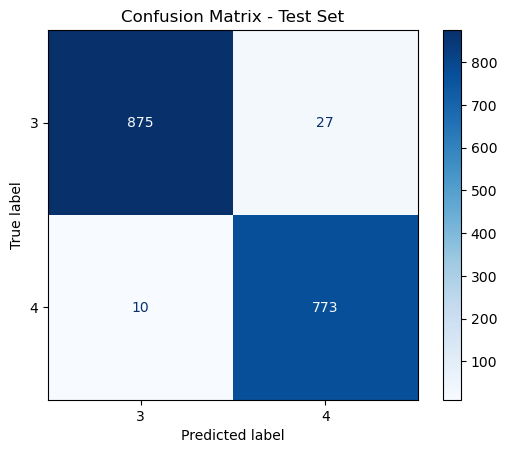

In [383]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'], display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - Test Set')
plt.show()

### PCA-Centroid Classifier

In [384]:
centroid_of_Z_3_train = np.mean(Z_train[Y_train==3], axis=0)
centroid_of_Z_4_train = np.mean(Z_train[Y_train==4], axis=0)

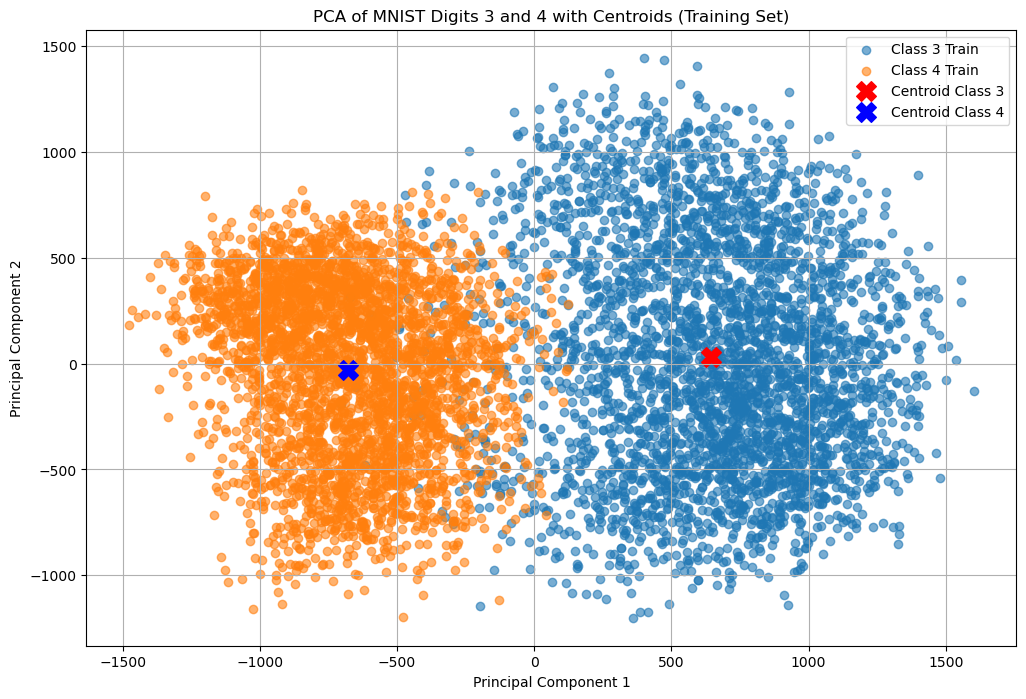

In [385]:
# Visualize centroids in PCA space
plt.figure(figsize=(12, 8))
plt.scatter(Z_train[Y_train==3, 0], Z_train[Y_train==3, 1], label='Class 3 Train', alpha=0.6)
plt.scatter(Z_train[Y_train==4, 0], Z_train[Y_train==4, 1], label='Class 4 Train', alpha=0.6)
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='blue', marker='X', s=200, label='Centroid Class 4')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 with Centroids (Training Set)')
plt.legend()
plt.grid()
plt.show()

In [386]:
def nearest_centroid_classifier_in_PCA_space(X):
    Z = (X - centroid_of_X_train) @ P_train.T 
    d_3 = np.linalg.norm(Z - centroid_of_Z_3_train, axis=1)
    d_4 = np.linalg.norm(Z - centroid_of_Z_4_train, axis=1)
    preds = (d_3 >= d_4).astype(int)  # 0 -> class 3, 1 -> class 4
    return preds

In [387]:
y_hat = nearest_centroid_classifier_in_PCA_space(X_test)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)

print("\nNearest Centroid Classifier")
for key, value in centroid_classifier_report.items():
    print(f"{key}: {value}")


Nearest Centroid Classifier
Accuracy: 0.9768545994065282
Macro-Precision: 0.9762304605431991
Macro-Recall: 0.9782128829647754
Macro-F1: 0.9767969354936092
Confusion Matrix: [[865  37]
 [  2 781]]
Classes: [0 1]


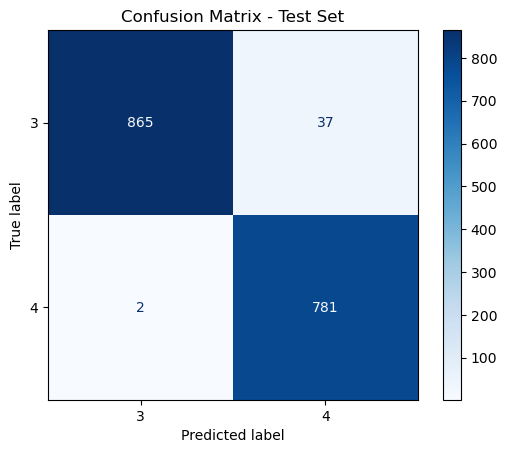

In [388]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'], display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - Test Set')
plt.show()

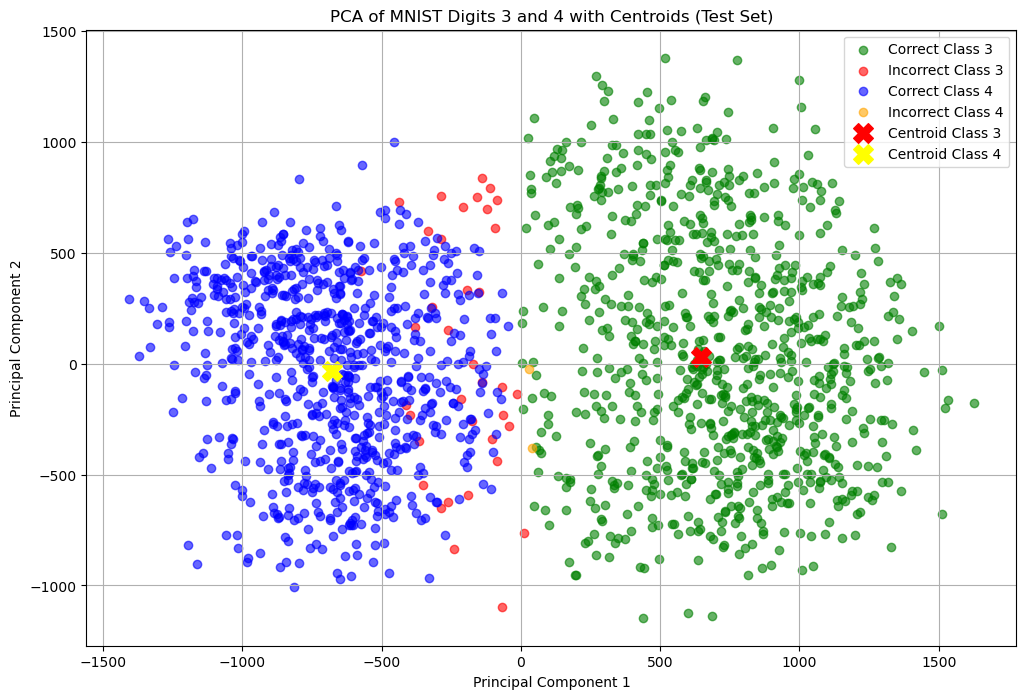

In [390]:
correct_3_classification = Z_test[(Y_test==3) & (y_hat==0)]
incorrect_3_classification = Z_test[(Y_test==3) & (y_hat==1)]
correct_4_classification = Z_test[(Y_test==4) & (y_hat==1)]
incorrect_4_classification = Z_test[(Y_test==4) & (y_hat==0)]



plt.figure(figsize=(12, 8))
plt.scatter(correct_3_classification[:, 0], correct_3_classification[:, 1], color='green', label='Correct Class 3', alpha=0.6)
plt.scatter(incorrect_3_classification[:, 0], incorrect_3_classification[:, 1], color='red', label='Incorrect Class 3', alpha=0.6)
plt.scatter(correct_4_classification[:, 0], correct_4_classification[:, 1], color='blue', label='Correct Class 4', alpha=0.6)
plt.scatter(incorrect_4_classification[:, 0], incorrect_4_classification[:, 1], color='orange', label='Incorrect Class 4', alpha=0.6)
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='yellow', marker='X', s=200, label='Centroid Class 4')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 3 and 4 with Centroids (Test Set)')
plt.legend()
plt.grid()
plt.show()

In [391]:

print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.9780415430267062
Nearest Centroid Classifier Accuracy: 0.9768545994065282


Logistic Regression Macro-F1:         0.9779607829551604
Nearest Centroid Classifier Macro-F1: 0.9767969354936092


Logistic Regression Macro-Precision:         0.9774752824858757
Nearest Centroid Classifier Macro-Precision: 0.9762304605431991


Logistic Regression Macro-Recall:         0.9786475633826348
Nearest Centroid Classifier Macro-Recall: 0.9782128829647754


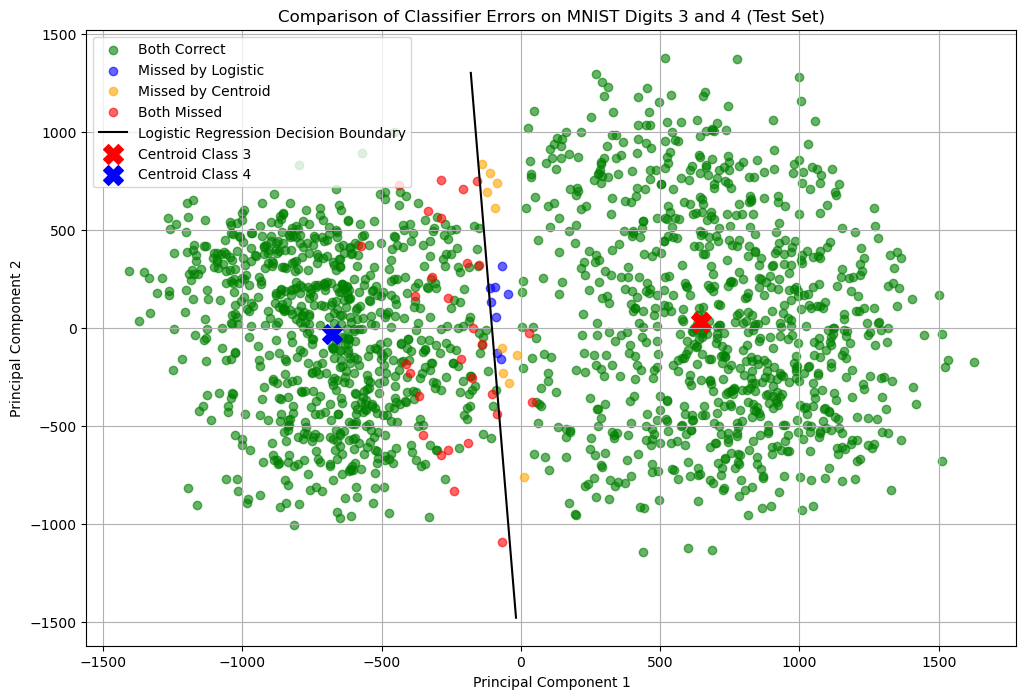

In [393]:
missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 48)
pc1_q3 = np.percentile(Z_train[:, 0], 51)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='red', marker='X', s=200, label='Centroid Class 3')
plt.scatter(centroid_of_Z_4_train[0], centroid_of_Z_4_train[1], color='blue', marker='X', s=200, label='Centroid Class 4') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 3 and 4 (Test Set)')
plt.legend()
plt.grid()
plt.show()

## 1 vs 7

In [345]:
filter_1or7 = (y==1) | (y==7)
X_filtered = X[filter_1or7]
Y_filtered = y[filter_1or7]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 7).astype(int)
Y_test_binary = (Y_test == 7).astype(int)
display_labels = ['1', '7']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_1_train = np.mean(Z_train[Y_train==1], axis=0)
centroid_of_Z_7_train = np.mean(Z_train[Y_train==7], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_1 = np.linalg.norm(Z - centroid_of_Z_1_train, axis=1)
d_7 = np.linalg.norm(Z - centroid_of_Z_7_train, axis=1)
y_hat = (d_1 >= d_7).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.9763346175013758
Nearest Centroid Classifier Accuracy: 0.9603742432581178


Logistic Regression Macro-F1:         0.9763180906799709
Nearest Centroid Classifier Macro-F1: 0.9602873358055093


Logistic Regression Macro-Precision:         0.9767399676285092
Nearest Centroid Classifier Macro-Precision: 0.9626551337380831


Logistic Regression Macro-Recall:         0.9761576121862844
Nearest Centroid Classifier Macro-Recall: 0.9598910553933033


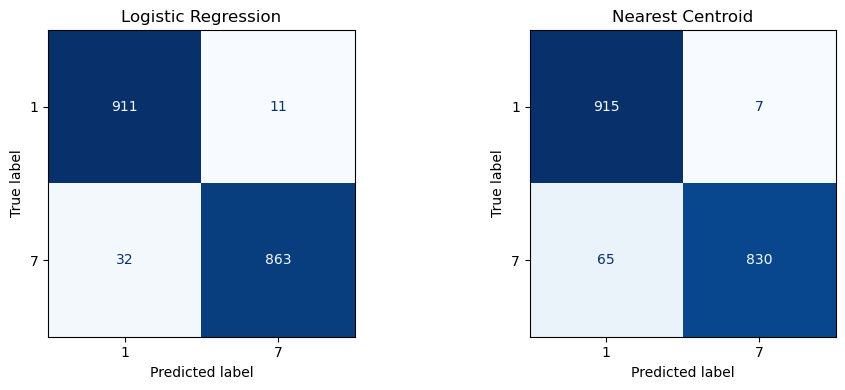

In [346]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

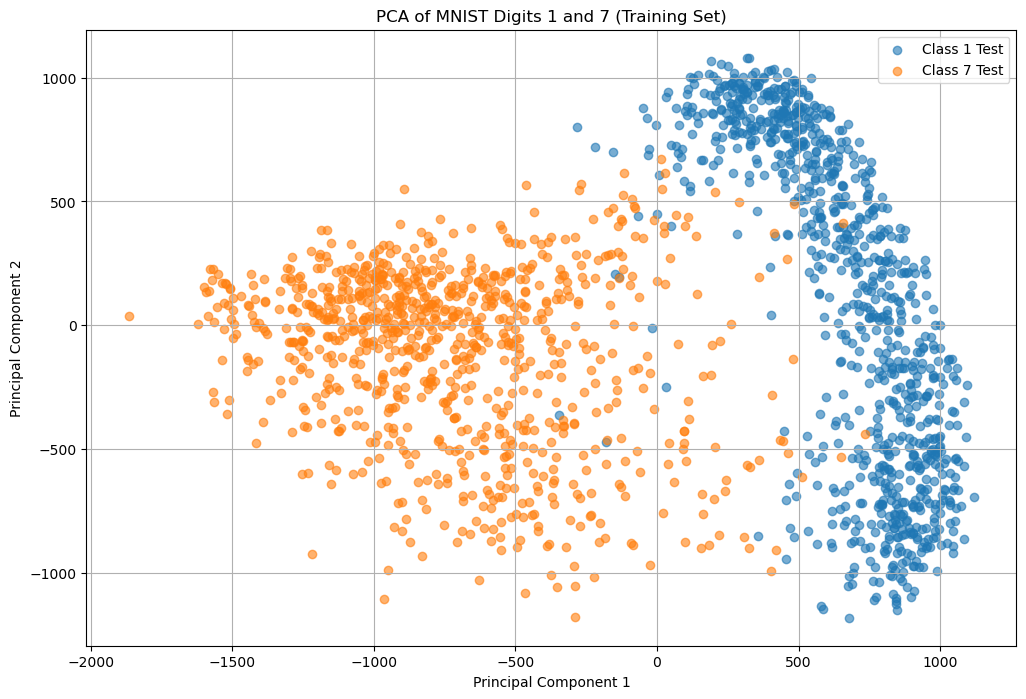

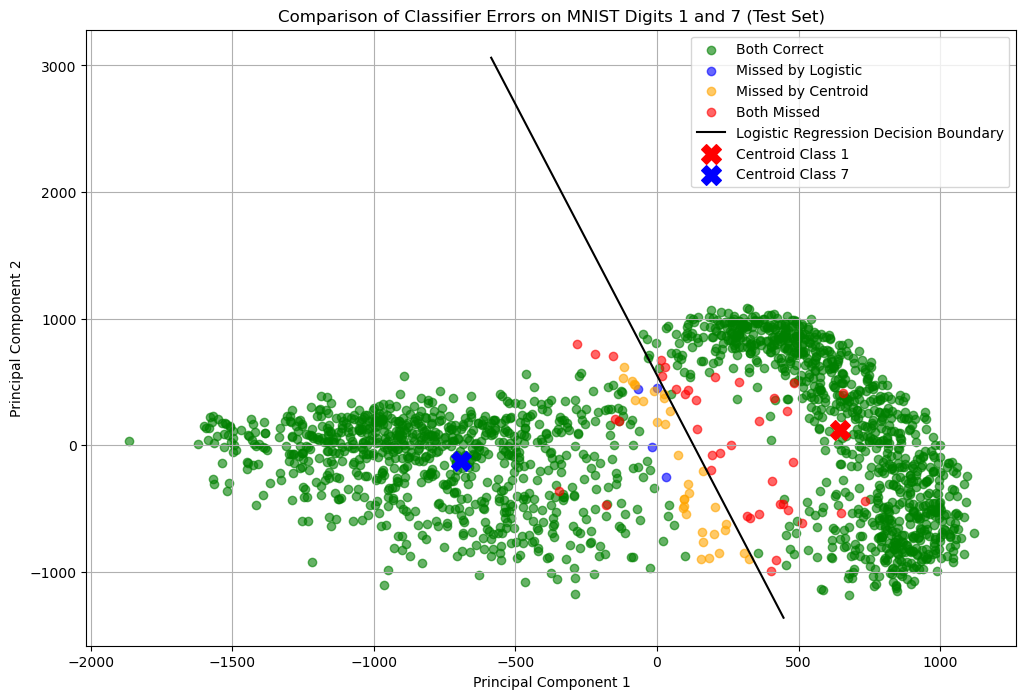

In [347]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==1, 0], Z_test[Y_test==1, 1], label='Class 1 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==7, 0], Z_test[Y_test==7, 1], label='Class 7 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 1 and 7 (Training Set)')
plt.legend()
plt.grid()
plt.show()

missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 30)
pc1_q3 = np.percentile(Z_train[:, 0], 60)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_1_train[0], centroid_of_Z_1_train[1], color='red', marker='X', s=200, label='Centroid Class 1')
plt.scatter(centroid_of_Z_7_train[0], centroid_of_Z_7_train[1], color='blue', marker='X', s=200, label='Centroid Class 7') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 1 and 7 (Test Set)')
plt.legend()
plt.grid()
plt.show()



## 5 vs 8

In [360]:
filter_5or8 = (y==5) | (y==8)
X_filtered = X[filter_5or8]
Y_filtered = y[filter_5or8]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 8).astype(int)
Y_test_binary = (Y_test == 8).astype(int)
display_labels = ['5', '8']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_5_train = np.mean(Z_train[Y_train==5], axis=0)
centroid_of_Z_8_train = np.mean(Z_train[Y_train==8], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_5 = np.linalg.norm(Z - centroid_of_Z_5_train, axis=1)
d_8 = np.linalg.norm(Z - centroid_of_Z_8_train, axis=1)
y_hat = (d_5 >= d_8).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.7296437659033079
Nearest Centroid Classifier Accuracy: 0.7404580152671756


Logistic Regression Macro-F1:         0.7293124146377928
Nearest Centroid Classifier Macro-F1: 0.740423981933416


Logistic Regression Macro-Precision:         0.7294846061704814
Nearest Centroid Classifier Macro-Precision: 0.7422471287013119


Logistic Regression Macro-Recall:         0.7304488820617854
Nearest Centroid Classifier Macro-Recall: 0.7428425133494259


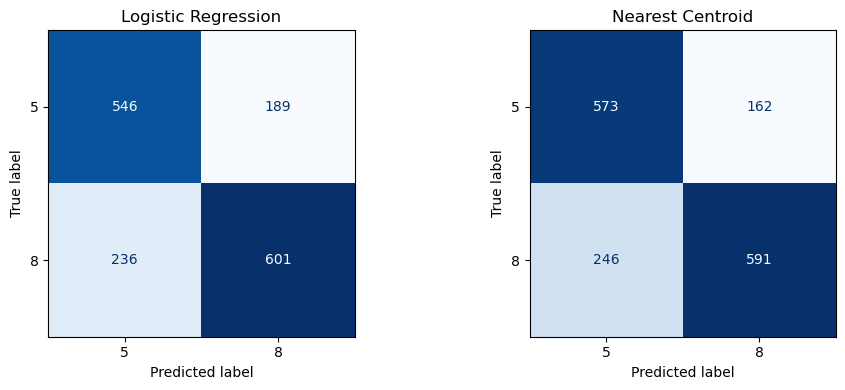

In [361]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

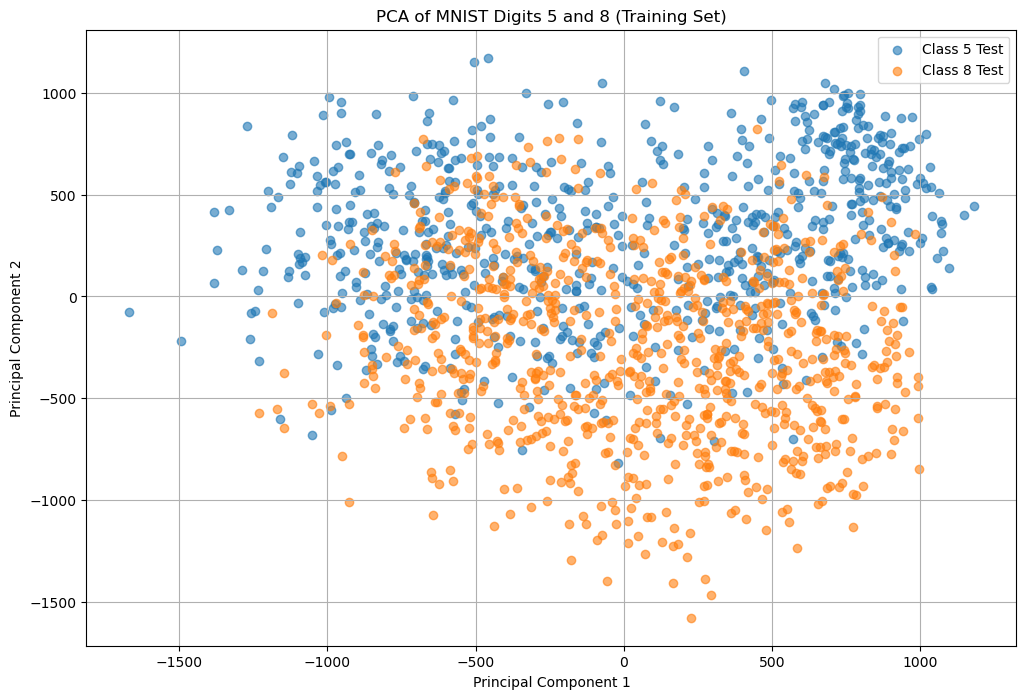

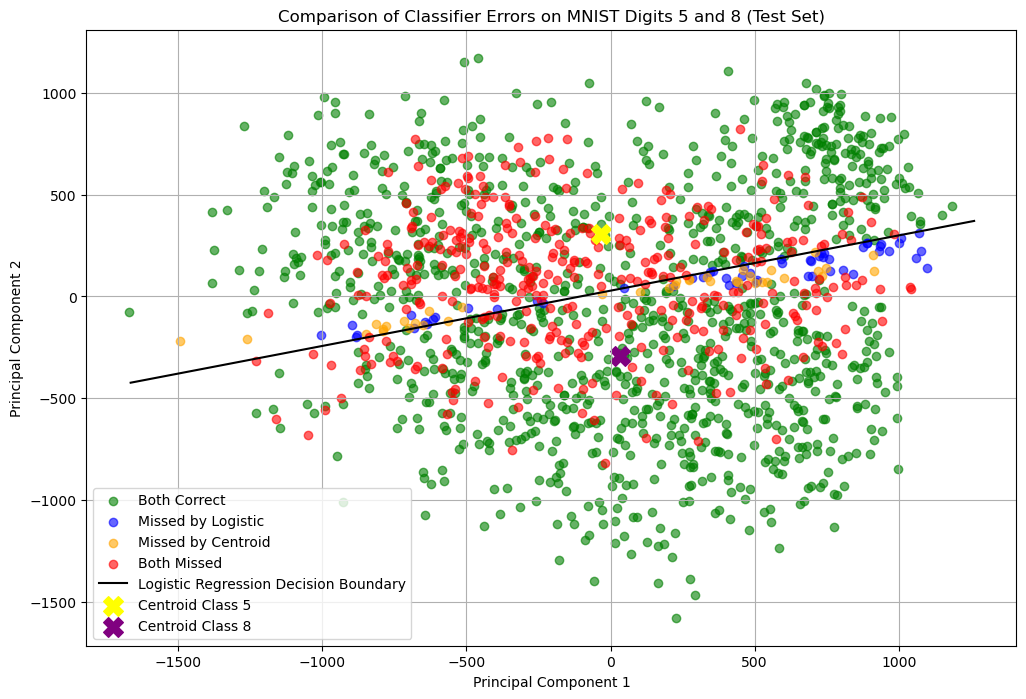

In [365]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==5, 0], Z_test[Y_test==5, 1], label='Class 5 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==8, 0], Z_test[Y_test==8, 1], label='Class 8 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 5 and 8 (Training Set)')
plt.legend()
plt.grid()
plt.show()

missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
#pc1_q1 = np.percentile(Z_train[:, 0], 20)
#pc1_q3 = np.percentile(Z_train[:, 0], 80)
pc1_range = np.array([Z_train[:, 0].min(), Z_train[:, 0].max()])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_5_train[0], centroid_of_Z_5_train[1], color='yellow', marker='X', s=200, label='Centroid Class 5')
plt.scatter(centroid_of_Z_8_train[0], centroid_of_Z_8_train[1], color='purple', marker='X', s=200, label='Centroid Class 8') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 5 and 8 (Test Set)')
plt.legend()
plt.grid()
plt.show()

## 2 vs 3

In [351]:
filter_2or3 = (y==2) | (y==3)
X_filtered = X[filter_2or3]
Y_filtered = y[filter_2or3]

N = X_filtered.shape[0]
random_indices = np.random.permutation(N)
N_trian = int(0.8 * N)
train_indices = random_indices[:N_trian]
test_indices = random_indices[N_trian:]
X_train = X_filtered[train_indices]
Y_train = Y_filtered[train_indices]
X_test = X_filtered[test_indices]
Y_test = Y_filtered[test_indices]



centroid_of_X_train = np.mean(X_train, axis=0)
X_train_centered = X_train - centroid_of_X_train
X_test_centered = X_test - centroid_of_X_train

U_train, s_train, VT_train = np.linalg.svd(X_train_centered, full_matrices=False)

k = 2
VTK_train = VT_train[:k]
P_train = VTK_train
Z_train = X_train_centered @ P_train.T
Z_test = X_test_centered @ P_train.T

Y_train_binary = (Y_train == 3).astype(int)
Y_test_binary = (Y_test == 3).astype(int)
display_labels = ['2', '3']

# Logistic regression
Z_train_bias = np.hstack((np.ones((Z_train.shape[0], 1)), Z_train))
Z_test_bias = np.hstack((np.ones((Z_test.shape[0], 1)), Z_test))
Theta0 = np.zeros(Z_train_bias.shape[1])
Theta, epoch, epoch_train_loss, epoch_train_acc = ADAM(l, grad_l, Z_train_bias, Y_train_binary, Theta0=Theta0, lr=0.1, epochs=10)
y_hat_test = (sigmoid(Z_test_bias @ Theta) >= 0.5).astype(int)
logistic_regression_report = classification_report(Y_test_binary, y_hat_test)

# Nearest Centroid Classifier
centroid_of_Z_2_train = np.mean(Z_train[Y_train==2], axis=0)
centroid_of_Z_3_train = np.mean(Z_train[Y_train==3], axis=0)
Z = (X_test - centroid_of_X_train) @ P_train.T 
d_2 = np.linalg.norm(Z - centroid_of_Z_2_train, axis=1)
d_3 = np.linalg.norm(Z - centroid_of_Z_3_train, axis=1)
y_hat = (d_2 >= d_3).astype(int)
centroid_classifier_report = classification_report(Y_test_binary, y_hat)


print(f"Logistic Regression Accuracy:         {logistic_regression_report['Accuracy']}")
print(f"Nearest Centroid Classifier Accuracy: {centroid_classifier_report['Accuracy']}")
print('\n')

print(f"Logistic Regression Macro-F1:         {logistic_regression_report['Macro-F1']}")
print(f"Nearest Centroid Classifier Macro-F1: {centroid_classifier_report['Macro-F1']}")
print('\n')

print(f"Logistic Regression Macro-Precision:         {logistic_regression_report['Macro-Precision']}")
print(f"Nearest Centroid Classifier Macro-Precision: {centroid_classifier_report['Macro-Precision']}")
print('\n')

print(f"Logistic Regression Macro-Recall:         {logistic_regression_report['Macro-Recall']}")
print(f"Nearest Centroid Classifier Macro-Recall: {centroid_classifier_report['Macro-Recall']}")


Logistic Regression Accuracy:         0.8686987104337632
Nearest Centroid Classifier Accuracy: 0.8985932004689332


Logistic Regression Macro-F1:         0.8686524974805906
Nearest Centroid Classifier Macro-F1: 0.8985714192433804


Logistic Regression Macro-Precision:         0.8692183295829119
Nearest Centroid Classifier Macro-Precision: 0.8989358775433847


Logistic Regression Macro-Recall:         0.8686987104337631
Nearest Centroid Classifier Macro-Recall: 0.8985932004689332


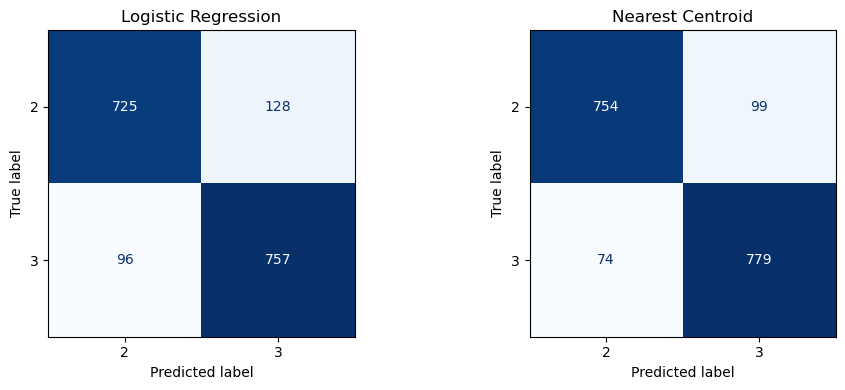

In [352]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(confusion_matrix=logistic_regression_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[0], cmap=plt.cm.Blues, colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix=centroid_classifier_report['Confusion Matrix'],display_labels=display_labels).plot(ax=axes[1], cmap=plt.cm.Blues, colorbar=False)
axes[1].set_title('Nearest Centroid')

plt.tight_layout()
plt.show()

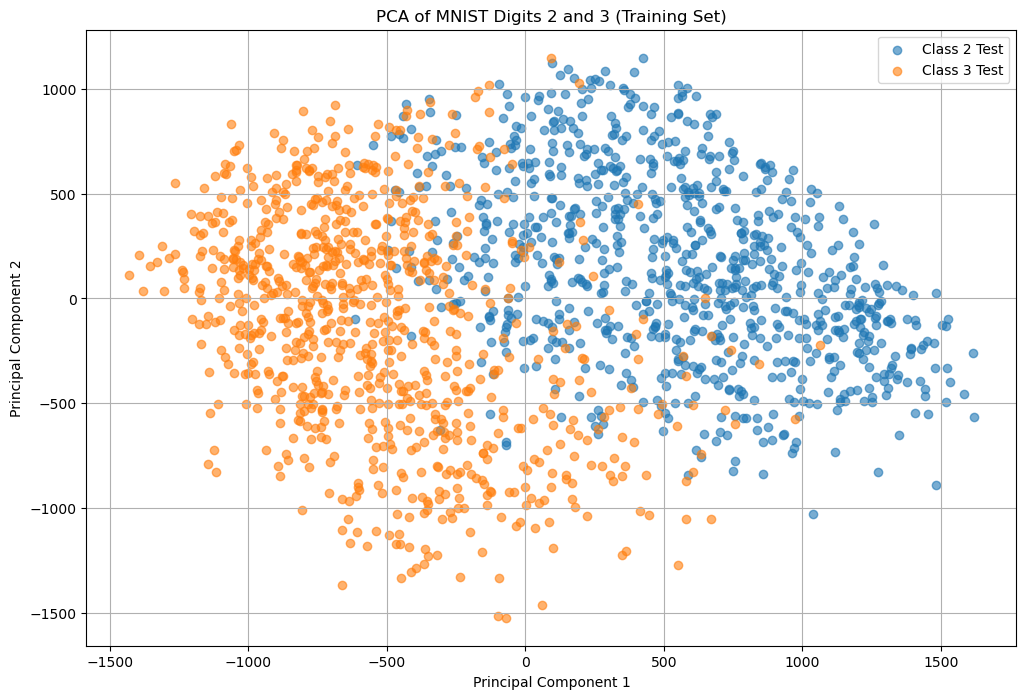

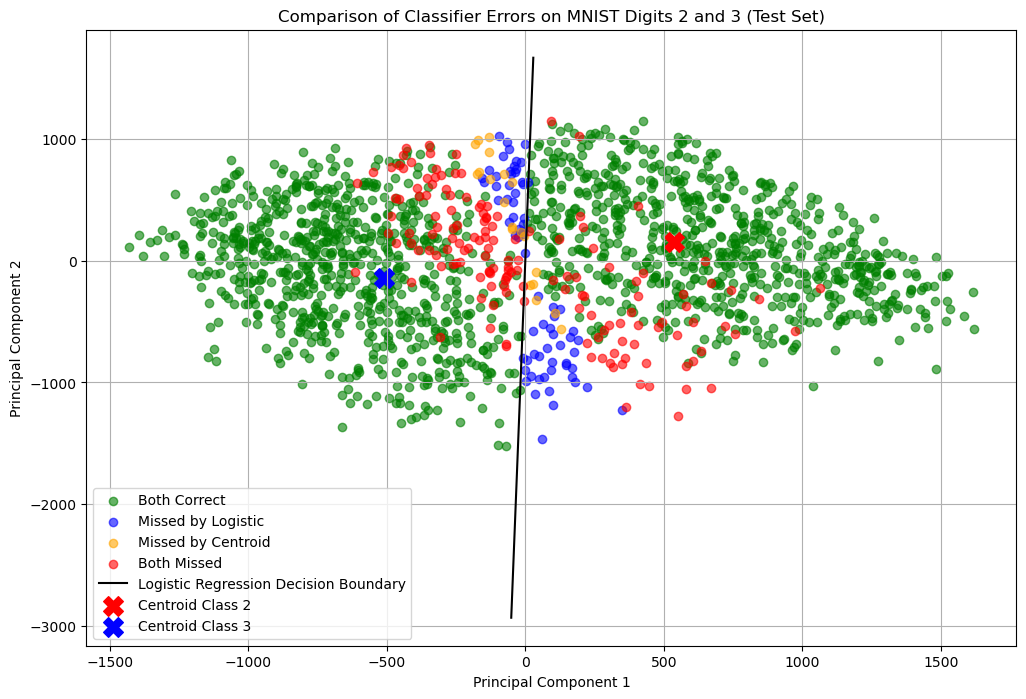

In [357]:
plt.figure(figsize=(12, 8))
plt.scatter(Z_test[Y_test==2, 0], Z_test[Y_test==2, 1], label='Class 2 Test', alpha=0.6)
plt.scatter(Z_test[Y_test==3, 0], Z_test[Y_test==3, 1], label='Class 3 Test', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of MNIST Digits 2 and 3 (Training Set)')
plt.legend()
plt.grid()
plt.show()


missclassified_by_logistic = (Y_test_binary != y_hat_test)
missclassified_by_centroid = (Y_test_binary != y_hat)
both_missclassified = missclassified_by_logistic & missclassified_by_centroid
both_classified_correctly = ~missclassified_by_logistic & ~missclassified_by_centroid

plt.figure(figsize=(12, 8))
plt.scatter(Z_test[both_classified_correctly, 0], Z_test[both_classified_correctly, 1], color='green', label='Both Correct', alpha=0.6)
plt.scatter(Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 0], Z_test[missclassified_by_logistic & ~missclassified_by_centroid, 1], color='blue', label='Missed by Logistic', alpha=0.6)
plt.scatter(Z_test[~missclassified_by_logistic & missclassified_by_centroid, 0], Z_test[~missclassified_by_logistic & missclassified_by_centroid, 1], color='orange', label='Missed by Centroid', alpha=0.6)
plt.scatter(Z_test[both_missclassified, 0], Z_test[both_missclassified, 1], color='red', label='Both Missed', alpha=0.6)

# Plot decision boundary
pc1_q1 = np.percentile(Z_train[:, 0], 50)
pc1_q3 = np.percentile(Z_train[:, 0], 53)
pc1_range = np.array([pc1_q1, pc1_q3])
pc2_vals = -(Theta[0] + Theta[1] * pc1_range) / Theta[2]
plt.plot(pc1_range, pc2_vals, label='Logistic Regression Decision Boundary', color='black')

# Plot centroids
plt.scatter(centroid_of_Z_2_train[0], centroid_of_Z_2_train[1], color='red', marker='X', s=200, label='Centroid Class 2')
plt.scatter(centroid_of_Z_3_train[0], centroid_of_Z_3_train[1], color='blue', marker='X', s=200, label='Centroid Class 3') 

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Comparison of Classifier Errors on MNIST Digits 2 and 3 (Test Set)')
plt.legend()
plt.grid()
plt.show()